# Epidemiological Intelligence — Exploratory Data Analysis

## Objetivo

Esta análise explora a relação entre variáveis climáticas e a ocorrência de doenças em municípios do Rio Grande do Sul entre 2015 e 2025.

A análise utiliza a camada Gold do pipeline de dados, armazenada no Google BigQuery.

### Principais objetivos

- Avaliar a qualidade e cobertura dos dados;
- Investigar valores ausentes;
- Analisar a distribuição dos casos epidemiológicos;
- Investigar padrões temporais e sazonais;
- Explorar as variáveis climáticas;
- Avaliar relações entre clima e ocorrência de doenças;
- Identificar padrões que possam orientar a etapa de modelagem.

In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.cloud import bigquery

pd.set_option("display.max_columns", None)

PROJECT_ID = "affable-alpha-506516-r7"

client = bigquery.Client(project=PROJECT_ID)

In [120]:
query = """
SELECT *
FROM `affable-alpha-506516-r7.epidemiological_intelligence.epidemiology_climate_monthly`
ORDER BY reference_date, municipality, disease
"""

df = client.query(query).to_dataframe()

c:\Users\eduar\Desktop\Projeto-Python\epidemiological-intelligence\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [121]:
df.shape

(21384, 19)

In [122]:
df.head()

,municipality,year,month,municipality_code,reference_date,cases,source_file,ingestion_timestamp,disease,precipitation_sum_mm,precipitation_avg_observation_mm,precipitation_max_observation_mm,temperature_avg_c,dew_point_avg_c,relative_humidity_avg_pct,atmospheric_pressure_avg_mb,wind_speed_avg_ms,wind_gust_max_ms,station_count
0,BAGE,2015,1,430160,2015-01-01,4,gs://epidemiological-intelligence/bronze/sinan...,2026-08-25 18:02:09.471128+00:00,ASMA,207.4,0.279139,27.0,23.01319,18.240915,76.601615,986.807268,3.125303,21.9,1
1,BAGE,2015,1,430160,2015-01-01,0,gs://epidemiological-intelligence/bronze/sinan...,2026-08-25 18:02:09.471128+00:00,BRONQUITE AGUDA,207.4,0.279139,27.0,23.01319,18.240915,76.601615,986.807268,3.125303,21.9,1
2,BAGE,2015,1,430160,2015-01-01,7,gs://epidemiological-intelligence/bronze/sinan...,2026-08-25 18:02:09.471128+00:00,BRONQUITE CRÔNICA,207.4,0.279139,27.0,23.01319,18.240915,76.601615,986.807268,3.125303,21.9,1
3,BAGE,2015,1,430160,2015-01-01,11,gs://epidemiological-intelligence/bronze/sinan...,2026-08-25 18:02:09.471128+00:00,INFARTO AGUDO DO MIOCÁRDIO,207.4,0.279139,27.0,23.01319,18.240915,76.601615,986.807268,3.125303,21.9,1
4,BAGE,2015,1,430160,2015-01-01,18,gs://epidemiological-intelligence/bronze/sinan...,2026-08-25 18:02:09.471128+00:00,INSUFICIÊNCIA CARDÍACA,207.4,0.279139,27.0,23.01319,18.240915,76.601615,986.807268,3.125303,21.9,1


In [123]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21384 entries, 0 to 21383
Data columns (total 19 columns):
 #   Column                            Non-Null Count  Dtype              
---  ------                            --------------  -----              
 0   municipality                      21384 non-null  str                
 1   year                              21384 non-null  Int64              
 2   month                             21384 non-null  Int64              
 3   municipality_code                 21384 non-null  str                
 4   reference_date                    21384 non-null  dbdate             
 5   cases                             20028 non-null  Int64              
 6   source_file                       21384 non-null  str                
 7   ingestion_timestamp               21384 non-null  datetime64[us, UTC]
 8   disease                           21384 non-null  str                
 9   precipitation_sum_mm              20022 non-null  float64            
 1

In [124]:
print(f"Linhas: {df.shape[0]:,}")
print(f"Colunas: {df.shape[1]}")
print(f"Municípios: {df['municipality'].nunique()}")
print(f"Doenças: {df['disease'].nunique()}")
print(f"Data inicial: {df['reference_date'].min()}")
print(f"Data final: {df['reference_date'].max()}")

Linhas: 21,384
Colunas: 19
Municípios: 27
Doenças: 6
Data inicial: 2015-01-01
Data final: 2025-12-01


In [125]:
df["disease"].value_counts()

disease
ASMA                          3564
BRONQUITE AGUDA               3564
BRONQUITE CRÔNICA             3564
INFARTO AGUDO DO MIOCÁRDIO    3564
INSUFICIÊNCIA CARDÍACA        3564
LEPTOSPIROSE                  3564
Name: count, dtype: int64

In [126]:
df.duplicated(
    subset=["municipality", "year", "month", "disease"]
).sum()

np.int64(0)

## 1. Data Quality

Antes da análise estatística e da modelagem, avaliamos a completude da base e a distribuição dos valores ausentes.

Valores ausentes podem ter significados diferentes dependendo da variável. Em particular, a ausência de `cases` não será considerada automaticamente equivalente a zero casos.

In [127]:
missing = (
    df.isna()
    .sum()
    .to_frame("missing")
)

missing["percentage"] = (
    missing["missing"] / len(df) * 100
).round(2)

missing.sort_values("percentage", ascending=False)

,missing,percentage
precipitation_max_observation_mm,1362,6.37
precipitation_avg_observation_mm,1362,6.37
precipitation_sum_mm,1362,6.37
cases,1356,6.34
wind_gust_max_ms,1308,6.12
wind_speed_avg_ms,1296,6.06
dew_point_avg_c,1056,4.94
relative_humidity_avg_pct,1050,4.91
atmospheric_pressure_avg_mb,822,3.84
temperature_avg_c,780,3.65


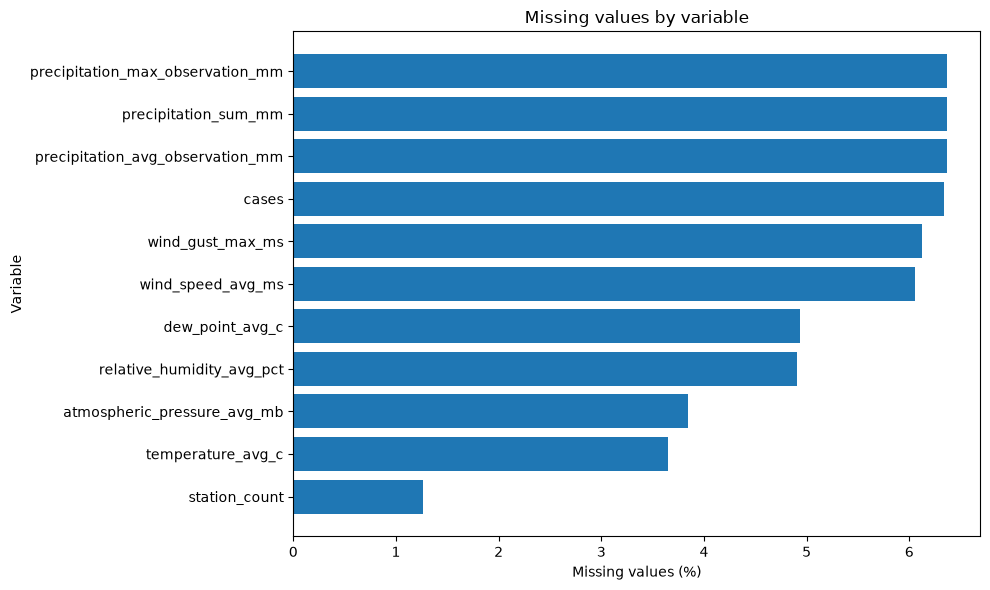

In [128]:
missing_plot = (
    missing[missing["missing"] > 0]
    .sort_values("percentage")
)

plt.figure(figsize=(10, 6))

plt.barh(
    missing_plot.index,
    missing_plot["percentage"]
)

plt.xlabel("Missing values (%)")
plt.ylabel("Variable")
plt.title("Missing values by variable")

plt.tight_layout()
plt.show()

In [129]:
cases_missing = df[df["cases"].isna()]

cases_missing.shape

(1356, 19)

In [130]:
cases_missing.groupby("disease").size().sort_values(ascending=False)

disease
LEPTOSPIROSE    1356
dtype: int64

In [131]:
cases_missing.groupby("municipality").size().sort_values(ascending=False)

municipality
BAGE                    132
CAMBARA DO SUL          120
SANTO AUGUSTO           120
SOLEDADE                120
LAGOA VERMELHA          108
PALMEIRA DAS MISSOES    108
CACAPAVA DO SUL          96
SAO BORJA                72
URUGUAIANA               72
SANTIAGO                 72
CANELA                   48
CRUZ ALTA                48
VACARIA                  48
TRAMANDAI                48
FREDERICO WESTPHALEN     48
RIO PARDO                36
TORRES                   24
CAMPO BOM                12
RIO GRANDE               12
PASSO FUNDO              12
dtype: int64

In [132]:
cases_missing.groupby("year").size()

year
2015    108
2016    120
2017    108
2018    120
2019     84
2020    204
2021    168
2022    168
2023    132
2024     48
2025     96
dtype: int64

### Valores ausentes nos dados epidemiológicos

Todos os valores ausentes identificados na variável `cases` estão associados aos dados de **leptospirose**.

A inspeção dos dados originais mostrou que a fonte utiliza diferentes representações para os registros epidemiológicos:

- Valores numéricos representam a quantidade registrada de casos.
- `-` é convertido para zero durante o processamento dos dados.
- `SEM` é preservado como informação ausente (`NULL`).
- Valores vazios na fonte também são preservados como `NULL`.

Dos **1.356 valores ausentes** encontrados na camada Gold:

- **1.334** correspondem originalmente ao valor `SEM`;
- **22** correspondem a valores vazios na fonte.

Esses valores ausentes não serão automaticamente substituídos por zero, pois ausência de informação e registro de zero casos representam situações epidemiológicas distintas.

Dessa forma, os valores ausentes serão preservados nesta etapa e tratados de acordo com as necessidades das análises estatísticas e dos modelos desenvolvidos posteriormente.

In [133]:
cases_summary = (
    df.groupby("disease")["cases"]
    .describe()
    .round(2)
)

cases_summary

,count,mean,std,min,25%,50%,75%,max
disease,,,,,,,,
ASMA,3564.0,7.39,31.17,0.0,0.0,1.0,3.0,359.0
BRONQUITE AGUDA,3564.0,10.92,51.83,0.0,0.0,1.0,4.0,644.0
BRONQUITE CRÔNICA,3564.0,10.95,26.73,0.0,2.0,5.0,9.0,233.0
INFARTO AGUDO DO MIOCÁRDIO,3564.0,17.12,49.83,0.0,0.0,2.0,9.0,390.0
INSUFICIÊNCIA CARDÍACA,3564.0,20.35,52.96,0.0,4.0,8.0,14.0,428.0
LEPTOSPIROSE,2208.0,0.77,3.93,0.0,0.0,0.0,1.0,130.0


In [134]:
cases_stats = (
    df.groupby("disease")["cases"]
    .agg(
        media="mean",
        variancia="var",
        mediana="median",
        maximo="max"
    )
    .round(2)
)

cases_stats["razao_variancia_media"] = (
    cases_stats["variancia"] / cases_stats["media"]
).round(2)

cases_stats

,media,variancia,mediana,maximo,razao_variancia_media
disease,,,,,
ASMA,7.39,971.28,1.0,359,131.43
BRONQUITE AGUDA,10.92,2686.67,1.0,644,246.03
BRONQUITE CRÔNICA,10.95,714.68,5.0,233,65.27
INFARTO AGUDO DO MIOCÁRDIO,17.12,2483.43,2.0,390,145.06
INSUFICIÊNCIA CARDÍACA,20.35,2804.83,8.0,428,137.83
LEPTOSPIROSE,0.77,15.44,0.0,130,20.05


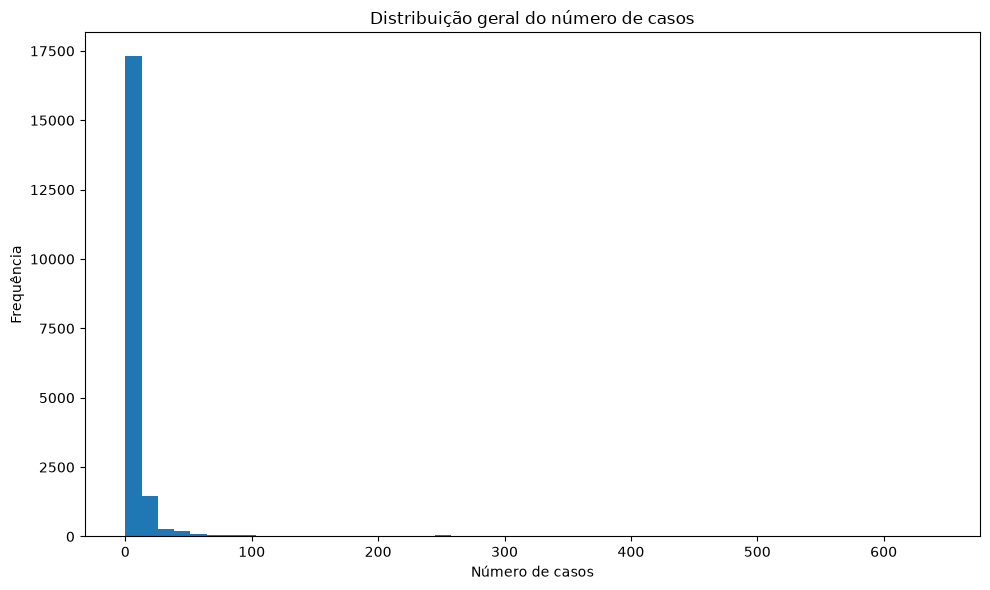

In [135]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["cases"].dropna(),
    bins=50
)

plt.xlabel("Número de casos")
plt.ylabel("Frequência")
plt.title("Distribuição geral do número de casos")

plt.tight_layout()
plt.show()

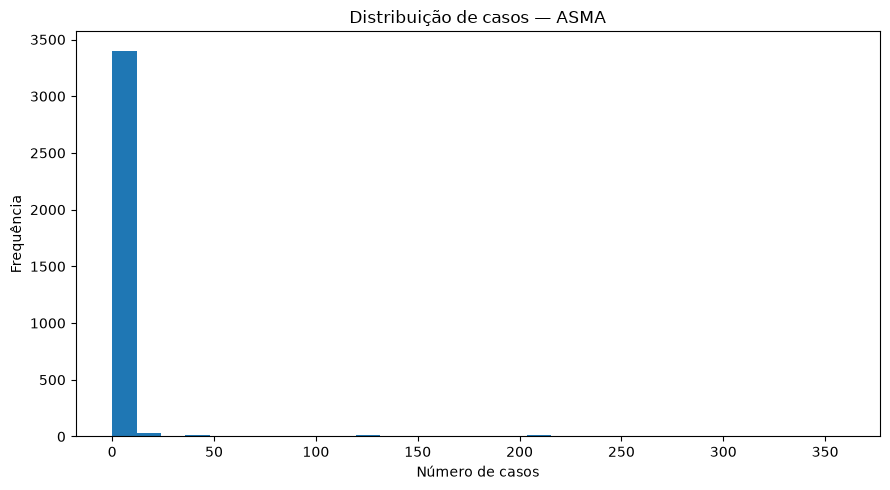

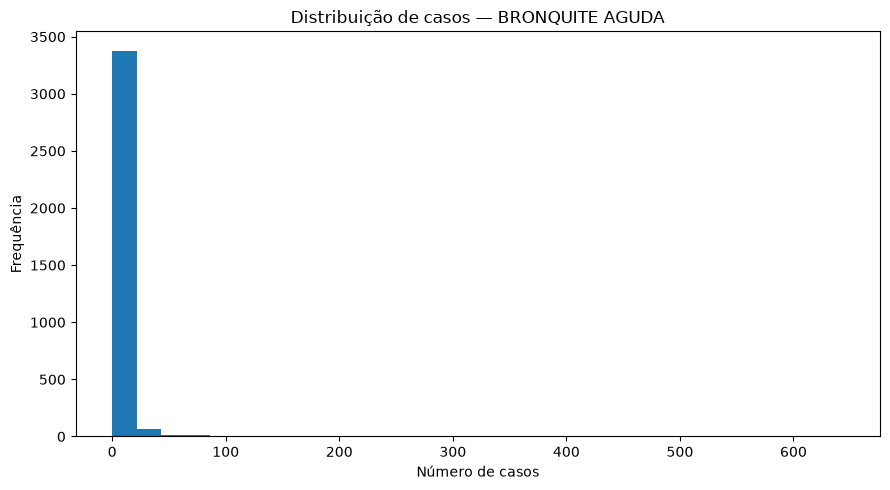

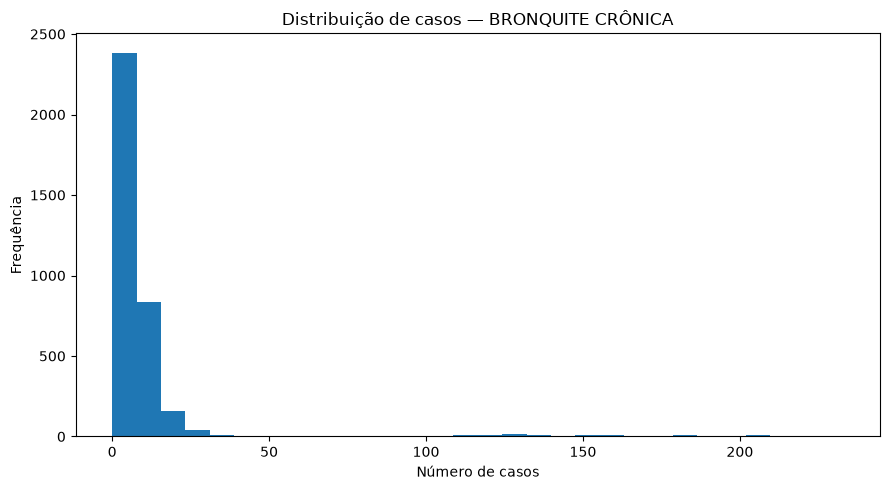

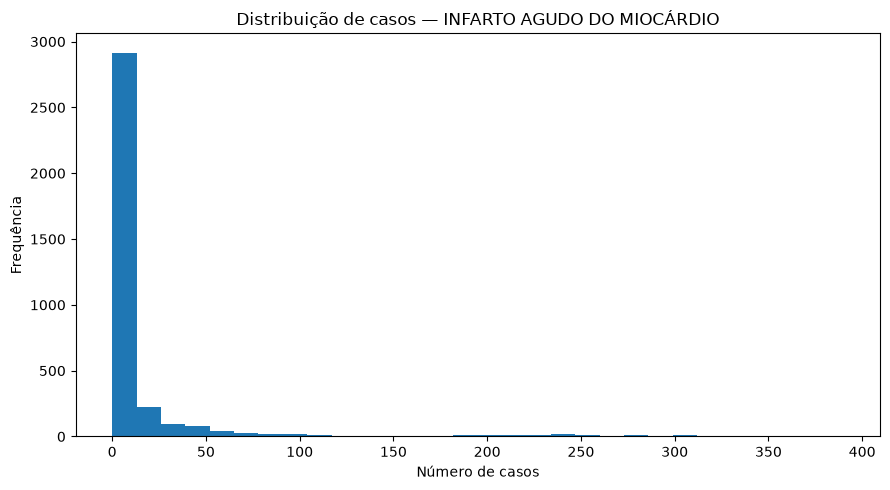

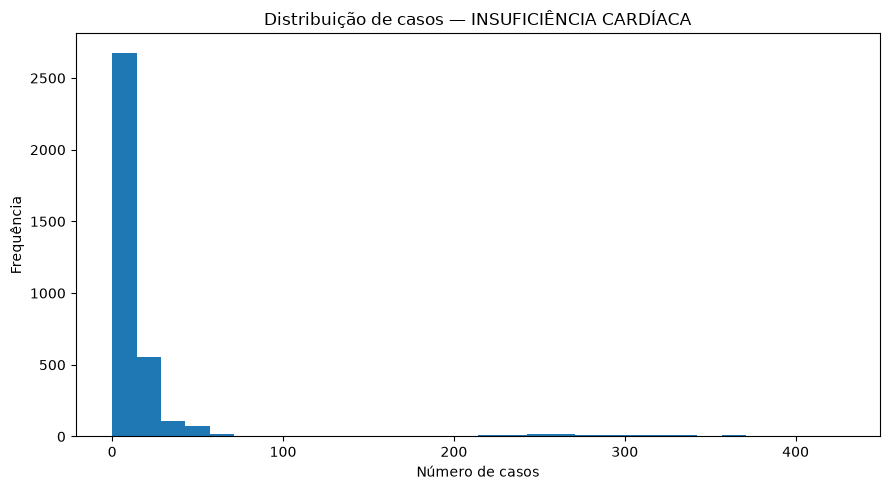

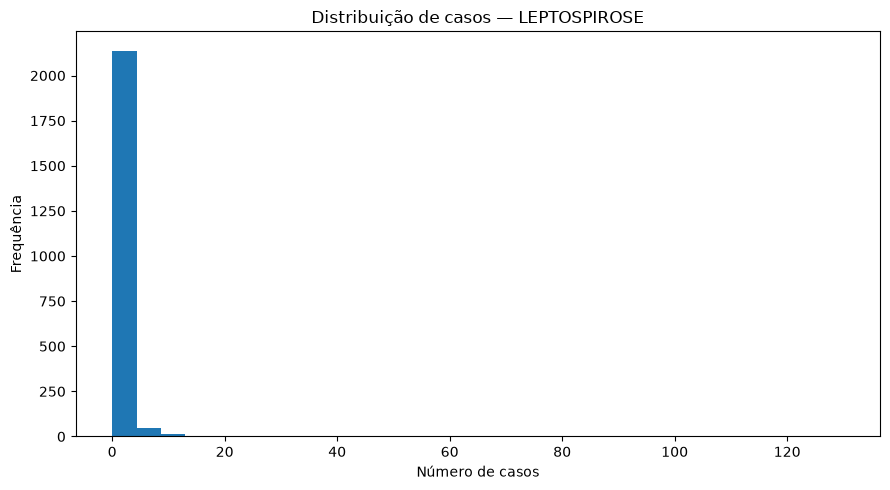

In [136]:
diseases = df["disease"].unique()

for disease in diseases:
    disease_data = df.loc[
        df["disease"] == disease,
        "cases"
    ].dropna()

    plt.figure(figsize=(9, 5))

    plt.hist(
        disease_data,
        bins=30
    )

    plt.xlabel("Número de casos")
    plt.ylabel("Frequência")
    plt.title(f"Distribuição de casos — {disease}")

    plt.tight_layout()
    plt.show()

In [137]:
zero_cases = (
    df.assign(is_zero=df["cases"].eq(0))
    .groupby("disease")
    .agg(
        observacoes=("cases", "count"),
        zeros=("is_zero", "sum")
    )
)

zero_cases["percentual_zeros"] = (
    zero_cases["zeros"] /
    zero_cases["observacoes"] *
    100
).round(2)

zero_cases

,observacoes,zeros,percentual_zeros
disease,,,
ASMA,3564,1299,36.45
BRONQUITE AGUDA,3564,1571,44.08
BRONQUITE CRÔNICA,3564,306,8.59
INFARTO AGUDO DO MIOCÁRDIO,3564,1139,31.96
INSUFICIÊNCIA CARDÍACA,3564,157,4.41
LEPTOSPIROSE,2208,1539,69.7


### Distribuição dos casos epidemiológicos

A análise da distribuição dos casos revelou diferenças importantes entre as doenças estudadas.

Todas as doenças apresentaram variância consideravelmente superior à média, indicando forte **sobredispersão** nos dados. A razão entre variância e média variou de aproximadamente 20 para leptospirose até 246 para bronquite aguda.

Esse comportamento é relevante porque a variável de interesse representa uma contagem de casos. Modelos baseados na distribuição de Poisson assumem uma relação mais próxima entre média e variância, condição que não é observada nos dados analisados.

Também foi identificada forte assimetria nas distribuições. Em diversas doenças, a mediana é consideravelmente inferior à média e existem valores máximos muito superiores à maioria das observações, indicando distribuições com cauda longa à direita.

Além disso, foi observada uma proporção elevada de registros com zero casos em algumas doenças. A leptospirose apresentou a maior proporção, com aproximadamente 69,7% das observações válidas iguais a zero, seguida por bronquite aguda (44,08%), asma (36,45%) e infarto agudo do miocárdio (31,96%).

Essas características reforçam a importância de avaliar modelos apropriados para dados de contagem e sobredispersão, como a **Regressão Binomial Negativa**, além do modelo OLS utilizado como referência comparativa.

A elevada ocorrência de zeros também será considerada durante a avaliação dos modelos, podendo motivar posteriormente experimentos com modelos específicos para excesso de zeros.

In [138]:
monthly_cases = (
    df.groupby(
        ["reference_date", "disease"],
        as_index=False
    )["cases"]
    .sum(min_count=1)
)

monthly_cases.head()

,reference_date,disease,cases
0,2015-01-01,ASMA,127
1,2015-01-01,BRONQUITE AGUDA,75
2,2015-01-01,BRONQUITE CRÔNICA,243
3,2015-01-01,INFARTO AGUDO DO MIOCÁRDIO,347
4,2015-01-01,INSUFICIÊNCIA CARDÍACA,497


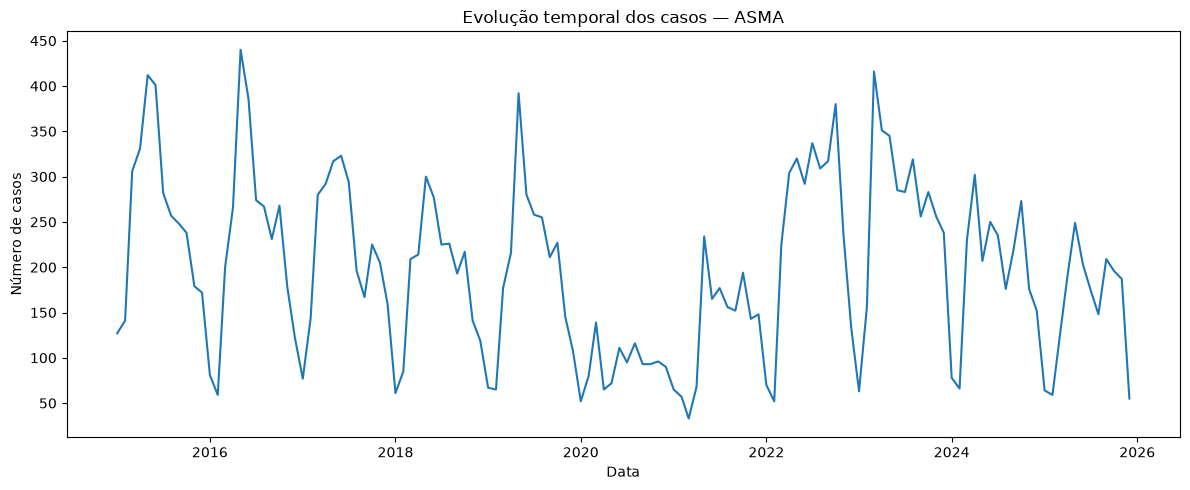

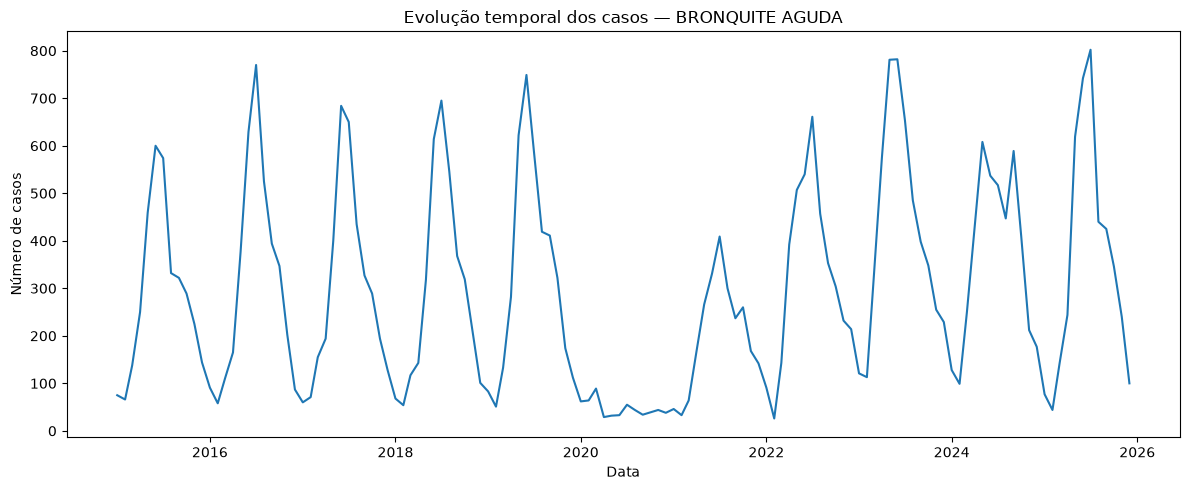

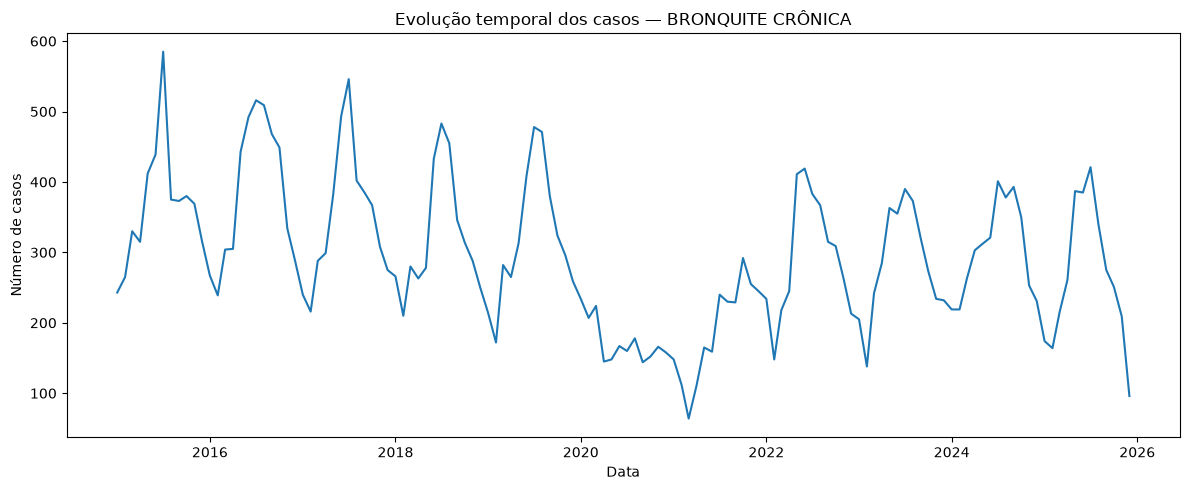

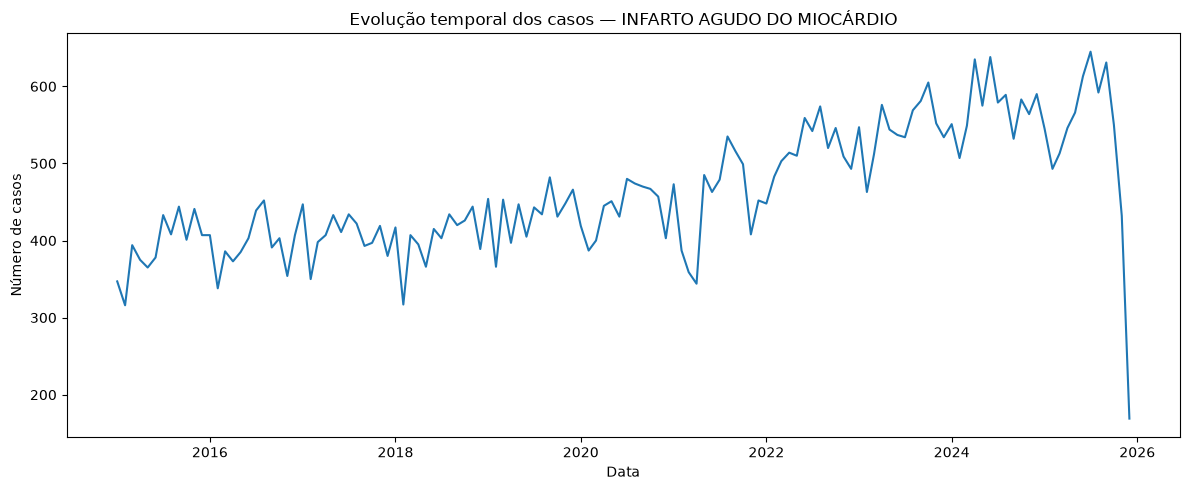

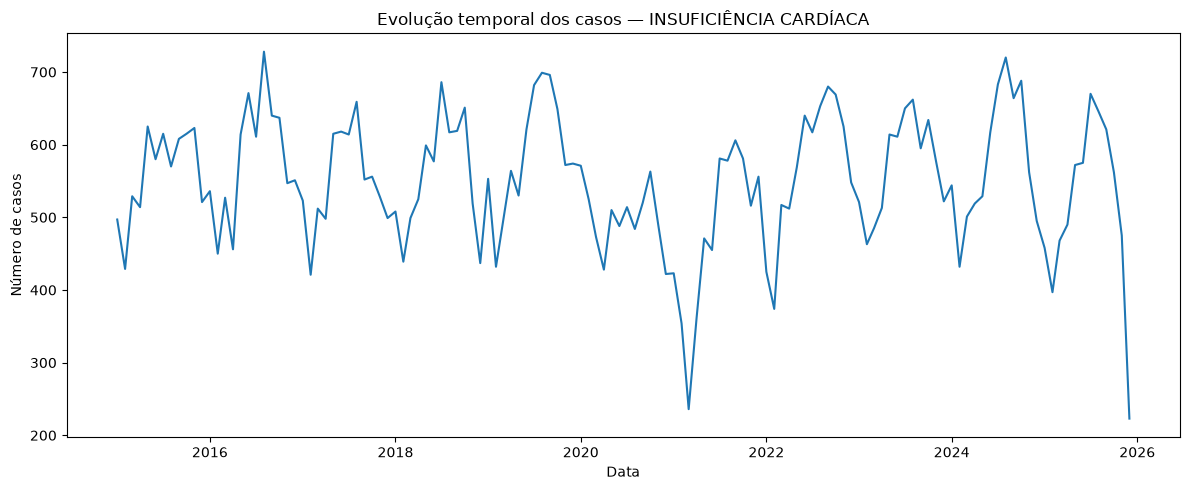

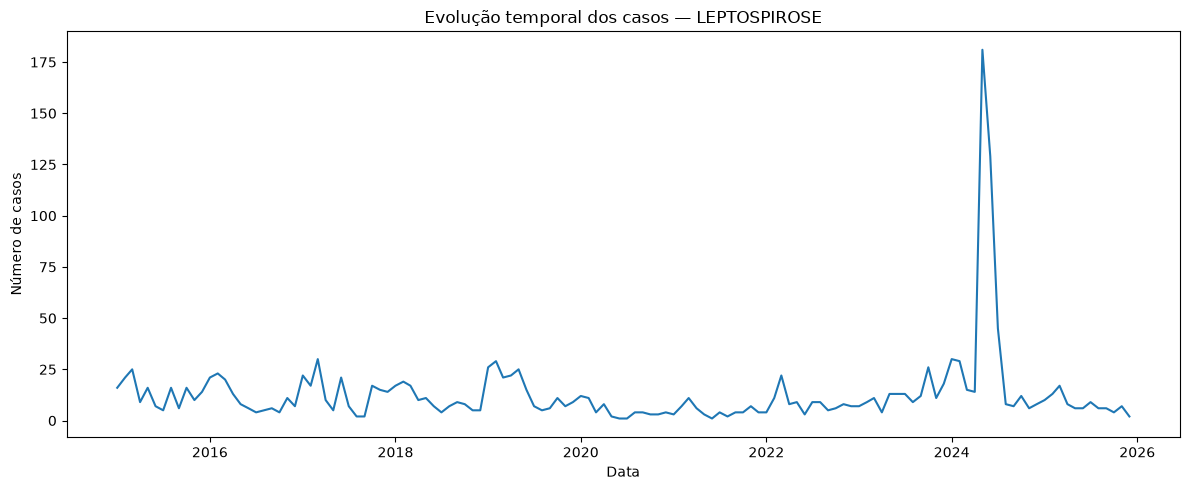

In [139]:
for disease in monthly_cases["disease"].unique():

    data = monthly_cases[
        monthly_cases["disease"] == disease
    ]

    plt.figure(figsize=(12, 5))

    plt.plot(
        data["reference_date"],
        data["cases"]
    )

    plt.xlabel("Data")
    plt.ylabel("Número de casos")
    plt.title(f"Evolução temporal dos casos — {disease}")

    plt.tight_layout()
    plt.show()

In [140]:
seasonality = (
    df.groupby(
        ["month", "disease"],
        as_index=False
    )["cases"]
    .mean()
)

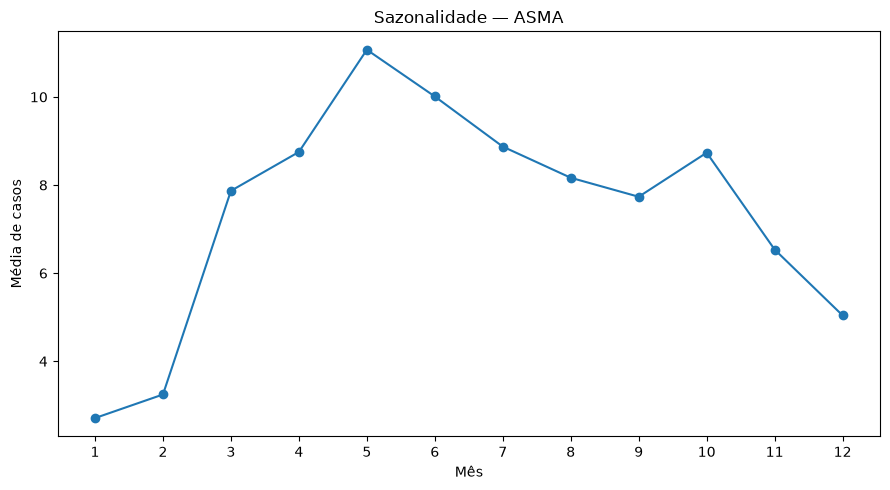

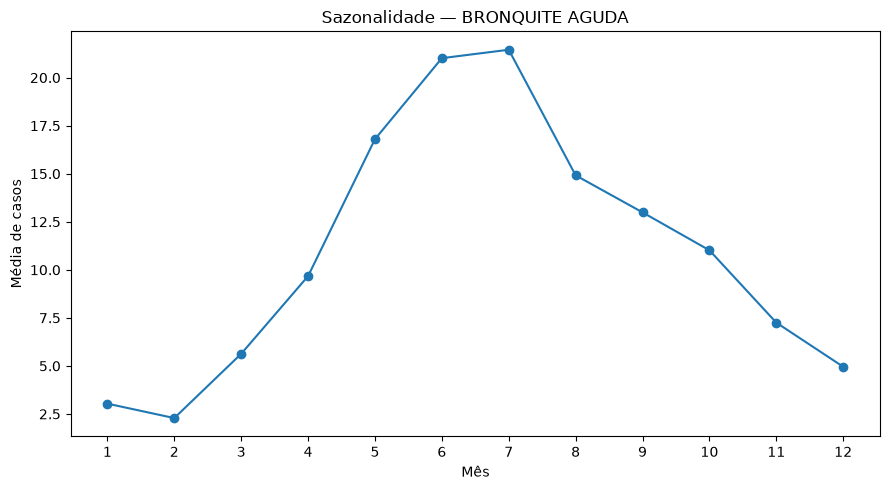

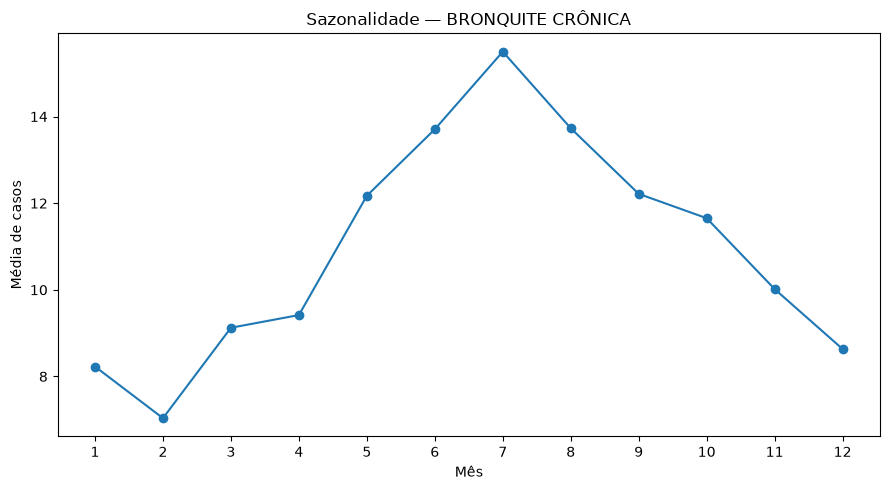

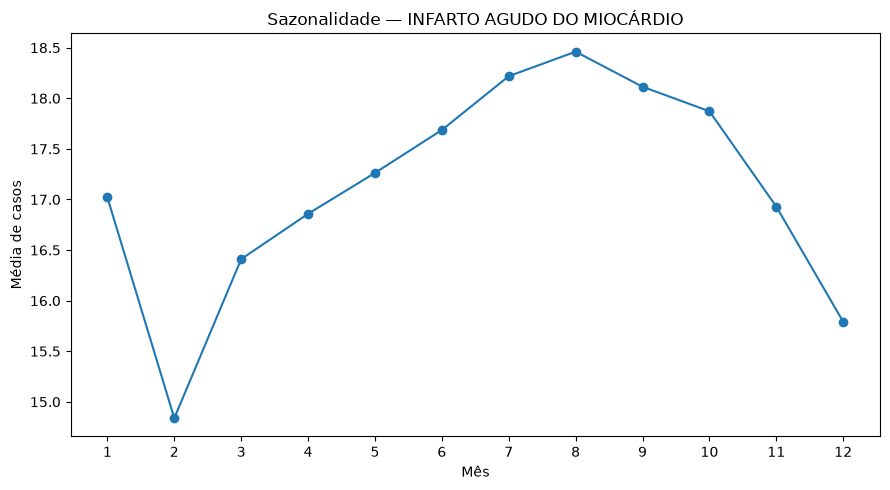

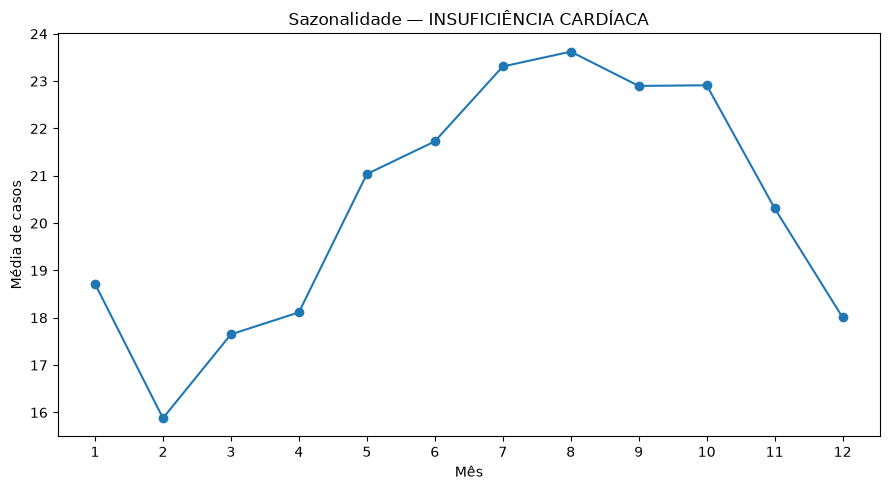

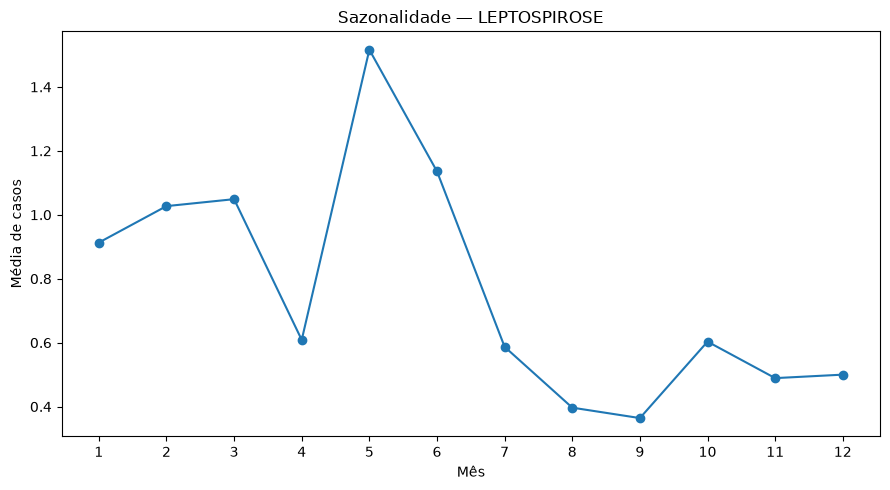

In [141]:
for disease in seasonality["disease"].unique():

    data = seasonality[
        seasonality["disease"] == disease
    ]

    plt.figure(figsize=(9, 5))

    plt.plot(
        data["month"],
        data["cases"],
        marker="o"
    )

    plt.xticks(range(1, 13))
    plt.xlabel("Mês")
    plt.ylabel("Média de casos")
    plt.title(f"Sazonalidade — {disease}")

    plt.tight_layout()
    plt.show()

### Evolução temporal dos casos

A análise das séries temporais evidencia comportamentos distintos entre as doenças estudadas.

As doenças respiratórias, especialmente asma, bronquite aguda e bronquite crônica, apresentam oscilações recorrentes ao longo do período analisado. A repetição de picos e vales sugere a existência de um componente sazonal, hipótese que será investigada posteriormente por meio da distribuição dos casos entre os meses do ano e da relação com as variáveis climáticas.

O infarto agudo do miocárdio apresenta comportamento diferente, com indícios de tendência de crescimento ao longo da série, principalmente nos anos mais recentes. A insuficiência cardíaca apresenta maior estabilidade no longo prazo, embora também sejam observadas oscilações ao longo do ano.

A leptospirose apresenta uma série caracterizada predominantemente por baixas contagens, acompanhada de um pico excepcional em 2024. Esse período coincide temporalmente com as enchentes de grande magnitude ocorridas no Rio Grande do Sul, constituindo uma hipótese relevante para investigação posterior. A possível relação será analisada em conjunto com os dados de precipitação antes de serem estabelecidas conclusões sobre sua associação.

Também foram observadas quedas acentuadas no final de algumas séries, especialmente no último período disponível. Antes da modelagem, será verificado se essas observações representam variações reais ou possível incompletude dos dados mais recentes.

In [142]:
check_2025 = (
    df[df["year"] == 2025]
    .groupby(["month", "disease"])
    .agg(
        casos=("cases", "sum"),
        municipios=("municipality", "nunique"),
        observacoes=("cases", "count")
    )
    .reset_index()
)

check_2025

,month,disease,casos,municipios,observacoes
0,1,ASMA,64,27,27
1,1,BRONQUITE AGUDA,77,27,27
2,1,BRONQUITE CRÔNICA,174,27,27
3,1,INFARTO AGUDO DO MIOCÁRDIO,545,27,27
4,1,INSUFICIÊNCIA CARDÍACA,458,27,27
...,...,...,...,...,...
67,12,BRONQUITE AGUDA,100,27,27
68,12,BRONQUITE CRÔNICA,96,27,27
69,12,INFARTO AGUDO DO MIOCÁRDIO,169,27,27
70,12,INSUFICIÊNCIA CARDÍACA,223,27,27


In [143]:
seasonality_table = (
    df.groupby(["disease", "month"])["cases"]
    .agg(
        media="mean",
        mediana="median",
        desvio_padrao="std"
    )
    .round(2)
    .reset_index()
)

seasonality_table

,disease,month,media,mediana,desvio_padrao
0,ASMA,1,2.71,0.0,10.37
1,ASMA,2,3.25,0.0,13.26
2,ASMA,3,7.87,1.0,32.37
3,ASMA,4,8.75,1.0,35.83
4,ASMA,5,11.07,2.0,45.38
...,...,...,...,...,...
67,LEPTOSPIROSE,8,0.4,0.0,1.11
68,LEPTOSPIROSE,9,0.36,0.0,1.17
69,LEPTOSPIROSE,10,0.6,0.0,1.76
70,LEPTOSPIROSE,11,0.49,0.0,1.21


In [144]:
peak_months = (
    seasonality_table
    .loc[
        seasonality_table
        .groupby("disease")["media"]
        .idxmax()
    ]
    [["disease", "month", "media"]]
    .sort_values("disease")
)

peak_months

,disease,month,media
4,ASMA,5,11.07
18,BRONQUITE AGUDA,7,21.45
30,BRONQUITE CRÔNICA,7,15.5
43,INFARTO AGUDO DO MIOCÁRDIO,8,18.46
55,INSUFICIÊNCIA CARDÍACA,8,23.62
64,LEPTOSPIROSE,5,1.52


### Sazonalidade dos casos

A análise dos casos por mês do ano revelou indícios de sazonalidade nas doenças estudadas.

As doenças respiratórias apresentaram maiores médias de casos durante o período de outono e inverno. A asma apresentou sua maior média em maio, enquanto bronquite aguda e bronquite crônica apresentaram seus maiores valores médios em julho.

Comportamento semelhante foi observado nas doenças cardiovasculares. Tanto o infarto agudo do miocárdio quanto a insuficiência cardíaca apresentaram suas maiores médias em agosto.

Esses resultados indicam uma concentração de maiores contagens entre maio e agosto para diferentes doenças. Entretanto, a coincidência temporal com os meses mais frios não permite concluir, isoladamente, que as condições climáticas sejam responsáveis pelo aumento dos casos. Essa hipótese será investigada posteriormente por meio da associação entre as variáveis meteorológicas e epidemiológicas.

A leptospirose apresentou sua maior média em maio. Esse resultado deve ser interpretado com cautela, pois a série contém um evento extremo em 2024 que pode influenciar significativamente a média histórica desse mês.

Também foi analisada a queda observada no final das séries temporais. Os 27 municípios permanecem representados em dezembro de 2025 para as demais doenças, indicando que a queda não é explicada simplesmente pela ausência de municípios na base. Ainda assim, não é possível descartar nesta etapa eventual incompletude ou atraso nos registros epidemiológicos mais recentes.

In [158]:
climate_vars = [
    "precipitation_sum_mm",
    "precipitation_avg_observation_mm",
    "precipitation_max_observation_mm",
    "temperature_avg_c",
    "dew_point_avg_c",
    "relative_humidity_avg_pct",
    "atmospheric_pressure_avg_mb",
    "wind_speed_avg_ms",
    "wind_gust_max_ms"
]

correlations = []

for disease in df["disease"].unique():
    disease_df = df[df["disease"] == disease]

    for variable in climate_vars:
        corr = disease_df["cases"].corr(
            disease_df[variable],
            method="spearman"
        )

        correlations.append({
            "disease": disease,
            "climate_variable": variable,
            "spearman": corr
        })

correlation_df = pd.DataFrame(correlations)

correlation_df["abs_spearman"] = correlation_df["spearman"].abs()

correlation_df.sort_values(
    ["disease", "abs_spearman"],
    ascending=[True, False]
)

,disease,climate_variable,spearman,abs_spearman
3,ASMA,temperature_avg_c,-0.119769,0.119769
4,ASMA,dew_point_avg_c,-0.119242,0.119242
6,ASMA,atmospheric_pressure_avg_mb,0.059178,0.059178
0,ASMA,precipitation_sum_mm,0.021585,0.021585
8,ASMA,wind_gust_max_ms,-0.019448,0.019448
5,ASMA,relative_humidity_avg_pct,0.018389,0.018389
1,ASMA,precipitation_avg_observation_mm,0.016497,0.016497
7,ASMA,wind_speed_avg_ms,-0.013449,0.013449
2,ASMA,precipitation_max_observation_mm,-0.008091,0.008091
15,BRONQUITE AGUDA,atmospheric_pressure_avg_mb,0.211766,0.211766


### Associação entre variáveis climáticas e casos

A correlação de Spearman foi utilizada inicialmente para avaliar associações monotônicas entre as variáveis climáticas e o número de casos de cada doença. A escolha dessa medida é adequada para esta etapa exploratória devido à forte assimetria das distribuições, presença de valores extremos e elevada frequência de zeros observada em algumas doenças.

De forma geral, as correlações contemporâneas encontradas foram fracas. O maior coeficiente observado ocorreu entre pressão atmosférica e infarto agudo do miocárdio (ρ ≈ 0,374).

Nas doenças respiratórias, foram observadas associações negativas entre temperatura média e casos de asma (ρ ≈ -0,120), bronquite aguda (ρ ≈ -0,202) e bronquite crônica (ρ ≈ -0,181). Esses resultados são consistentes com o padrão sazonal identificado anteriormente, no qual maiores contagens foram observadas durante os meses mais frios.

Para leptospirose, a associação contemporânea com precipitação foi baixa (ρ ≈ 0,064). Esse resultado não descarta uma possível relação com eventos de chuva, pois seus efeitos epidemiológicos podem ocorrer com defasagem temporal e eventos extremos podem não ser adequadamente representados por uma correlação global calculada para todo o período.

As correlações observadas possuem caráter exploratório e não devem ser interpretadas como relações causais. Além disso, variáveis meteorológicas podem apresentar correlação entre si, aspecto que deverá ser considerado durante a modelagem multivariada.

### Comparação das métricas de precipitação

A inclusão de diferentes representações da precipitação mostrou que o modo de agregação da variável climática influencia sua associação com os casos registrados.

Para leptospirose, a precipitação máxima por observação apresentou correlação de Spearman de aproximadamente 0,106, superior à precipitação acumulada mensal (0,064) e à precipitação média por observação (0,050).

Embora todas as associações permaneçam fracas na análise agregada, o resultado sugere que medidas relacionadas à intensidade dos eventos de precipitação podem preservar informações que são diluídas quando a chuva é representada apenas por médias ou acumulados mensais.

Esse resultado não estabelece causalidade e será investigado posteriormente considerando defasagens temporais, diferenças entre municípios e eventos extremos.

In [161]:
df["precipitation_sum_mm"].shift(1)

0          NaN
1        207.4
2        207.4
3        207.4
4        207.4
         ...  
21379     26.2
21380     26.2
21381     26.2
21382     26.2
21383     26.2
Name: precipitation_sum_mm, Length: 21384, dtype: float64

In [162]:
df_lag = df.sort_values(
    ["municipality", "reference_date"]
).copy()

In [163]:
lag_results = []

for disease in df_lag["disease"].unique():
    disease_df = df_lag[
        df_lag["disease"] == disease
    ].copy()

    for variable in climate_vars:

        for lag in range(4):

            lag_column = (
                disease_df
                .groupby("municipality")[variable]
                .shift(lag)
            )

            valid = (
                disease_df["cases"].notna()
                & lag_column.notna()
            )

            corr = disease_df.loc[valid, "cases"].corr(
                lag_column[valid],
                method="spearman"
            )

            lag_results.append({
                "disease": disease,
                "climate_variable": variable,
                "lag_months": lag,
                "n": valid.sum(),
                "spearman": corr
            })

lag_correlation_df = pd.DataFrame(lag_results)

lag_correlation_df["abs_spearman"] = (
    lag_correlation_df["spearman"].abs()
)

In [164]:
best_lags = (
    lag_correlation_df
    .sort_values(
        "abs_spearman",
        ascending=False
    )
    .groupby(
        ["disease", "climate_variable"],
        as_index=False
    )
    .first()
)

display(
    best_lags.sort_values(
        ["disease", "abs_spearman"],
        ascending=[True, False]
    )
)

,disease,climate_variable,lag_months,n,spearman,abs_spearman
6,ASMA,temperature_avg_c,0,3434,-0.119769,0.119769
1,ASMA,dew_point_avg_c,0,3388,-0.119242,0.119242
0,ASMA,atmospheric_pressure_avg_mb,0,3427,0.059178,0.059178
8,ASMA,wind_speed_avg_ms,3,3279,-0.057333,0.057333
5,ASMA,relative_humidity_avg_pct,1,3365,0.052685,0.052685
3,ASMA,precipitation_max_observation_mm,3,3269,0.044533,0.044533
7,ASMA,wind_gust_max_ms,3,3277,-0.028747,0.028747
2,ASMA,precipitation_avg_observation_mm,1,3314,0.026127,0.026127
4,ASMA,precipitation_sum_mm,3,3269,-0.022441,0.022441
9,BRONQUITE AGUDA,atmospheric_pressure_avg_mb,1,3403,0.215014,0.215014


In [165]:
display(
    lag_correlation_df[
        (lag_correlation_df["disease"] == "LEPTOSPIROSE")
        &
        (
            lag_correlation_df["climate_variable"]
            .str.contains("precipitation")
        )
    ].sort_values(
        ["climate_variable", "lag_months"]
    )
)

,disease,climate_variable,lag_months,n,spearman,abs_spearman
184,LEPTOSPIROSE,precipitation_avg_observation_mm,0,2063,0.049634,0.049634
185,LEPTOSPIROSE,precipitation_avg_observation_mm,1,2048,0.053190,0.053190
186,LEPTOSPIROSE,precipitation_avg_observation_mm,2,2035,0.032074,0.032074
187,LEPTOSPIROSE,precipitation_avg_observation_mm,3,2019,0.041016,0.041016
188,LEPTOSPIROSE,precipitation_max_observation_mm,0,2063,0.106438,0.106438
189,LEPTOSPIROSE,precipitation_max_observation_mm,1,2048,0.124591,0.124591
190,LEPTOSPIROSE,precipitation_max_observation_mm,2,2035,0.095112,0.095112
191,LEPTOSPIROSE,precipitation_max_observation_mm,3,2019,0.069770,0.069770
180,LEPTOSPIROSE,precipitation_sum_mm,0,2063,0.063987,0.063987
181,LEPTOSPIROSE,precipitation_sum_mm,1,2048,0.060887,0.060887


### Análise de defasagem temporal das variáveis climáticas

Foram avaliadas defasagens de 0 a 3 meses entre as variáveis climáticas e o número de casos, respeitando a sequência temporal individual de cada município.

De forma geral, a inclusão de defasagens não produziu aumentos expressivos nas correlações para a maioria das doenças. Nas doenças respiratórias, temperatura e ponto de orvalho mantiveram suas maiores associações no próprio mês ou com pequenas defasagens.

Para bronquite aguda, a pressão atmosférica apresentou sua maior associação com defasagem de um mês (ρ ≈ 0,215). No infarto agudo do miocárdio, a pressão atmosférica também apresentou a maior correlação entre as variáveis analisadas, com lag de um mês (ρ ≈ 0,374).

Na leptospirose, o ponto de orvalho apresentou sua maior associação com defasagem de um mês (ρ ≈ 0,254), seguido pela temperatura média também com lag de um mês (ρ ≈ 0,214). A precipitação média mensal apresentou correlação baixa em todas as defasagens avaliadas.

Os resultados indicam que a relação entre clima e ocorrência de doenças pode não ser adequadamente representada apenas por associações simples entre uma variável climática e o número de casos. Fatores como sazonalidade, diferenças entre municípios, eventos climáticos extremos e a interação entre variáveis meteorológicas deverão ser considerados durante a etapa de modelagem.

In [151]:
municipality_correlations = []

for disease in df["disease"].unique():

    disease_df = df[
        df["disease"] == disease
    ]

    for municipality in disease_df["municipality"].unique():

        municipality_df = disease_df[
            disease_df["municipality"] == municipality
        ]

        for variable in climate_vars:

            valid = municipality_df[
                ["cases", variable]
            ].dropna()

            if len(valid) < 12:
                continue

            corr = valid["cases"].corr(
                valid[variable],
                method="spearman"
            )

            municipality_correlations.append({
                "disease": disease,
                "municipality": municipality,
                "climate_variable": variable,
                "n": len(valid),
                "spearman": corr
            })


municipality_corr_df = pd.DataFrame(
    municipality_correlations
)

municipality_corr_df["abs_spearman"] = (
    municipality_corr_df["spearman"].abs()
)

In [152]:
municipality_corr_df.sort_values(
    "abs_spearman",
    ascending=False
).head(30)

,disease,municipality,climate_variable,n,spearman,abs_spearman
366,BRONQUITE AGUDA,PORTO ALEGRE,atmospheric_pressure_avg_mb,132,0.736800,0.736800
363,BRONQUITE AGUDA,PORTO ALEGRE,temperature_avg_c,132,-0.723497,0.723497
365,BRONQUITE AGUDA,PORTO ALEGRE,relative_humidity_avg_pct,132,0.650812,0.650812
246,BRONQUITE AGUDA,BAGE,temperature_avg_c,130,-0.638305,0.638305
606,BRONQUITE CRÔNICA,PORTO ALEGRE,temperature_avg_c,132,-0.636864,0.636864
364,BRONQUITE AGUDA,PORTO ALEGRE,dew_point_avg_c,132,-0.633032,0.633032
1093,INSUFICIÊNCIA CARDÍACA,PORTO ALEGRE,dew_point_avg_c,132,-0.628029,0.628029
609,BRONQUITE CRÔNICA,PORTO ALEGRE,atmospheric_pressure_avg_mb,132,0.617025,0.617025
354,BRONQUITE AGUDA,PASSO FUNDO,temperature_avg_c,132,-0.615371,0.615371
1092,INSUFICIÊNCIA CARDÍACA,PORTO ALEGRE,temperature_avg_c,132,-0.599296,0.599296


In [153]:
lepto_precip_valid = (
    municipality_corr_df[
        (municipality_corr_df["disease"] == "LEPTOSPIROSE") &
        (
            municipality_corr_df["climate_variable"]
            == "precipitation_sum_mm"
        ) &
        (municipality_corr_df["n"] >= 60)
    ]
    .sort_values(
        "abs_spearman",
        ascending=False
    )
)

lepto_precip_valid

,disease,municipality,climate_variable,n,spearman,abs_spearman
1251,LEPTOSPIROSE,CAMPO BOM,precipitation_sum_mm,117,0.240136,0.240136
1260,LEPTOSPIROSE,CANELA,precipitation_sum_mm,81,0.224719,0.224719
1269,LEPTOSPIROSE,CRUZ ALTA,precipitation_sum_mm,82,0.223634,0.223634
1359,LEPTOSPIROSE,SANTA ROSA,precipitation_sum_mm,104,0.217524,0.217524
1323,LEPTOSPIROSE,PORTO ALEGRE,precipitation_sum_mm,132,0.185769,0.185769
1350,LEPTOSPIROSE,SANTA MARIA,precipitation_sum_mm,130,0.143971,0.143971
1314,LEPTOSPIROSE,PASSO FUNDO,precipitation_sum_mm,120,0.143047,0.143047
1440,LEPTOSPIROSE,VACARIA,precipitation_sum_mm,82,0.140926,0.140926
1368,LEPTOSPIROSE,SANTIAGO,precipitation_sum_mm,60,-0.065115,0.065115
1215,LEPTOSPIROSE,BENTO GONCALVES,precipitation_sum_mm,122,0.058105,0.058105


In [166]:
municipal_lag_results = []

lepto = (
    df[df["disease"] == "LEPTOSPIROSE"]
    .sort_values(["municipality", "reference_date"])
    .copy()
)

precipitation_vars = [
    "precipitation_sum_mm",
    "precipitation_avg_observation_mm",
    "precipitation_max_observation_mm"
]

for municipality in lepto["municipality"].unique():

    city_df = (
        lepto[lepto["municipality"] == municipality]
        .sort_values("reference_date")
        .copy()
    )

    for variable in precipitation_vars:

        for lag in range(4):

            lagged = city_df[variable].shift(lag)

            valid = (
                city_df["cases"].notna()
                & lagged.notna()
            )

            n = valid.sum()

            # evita correlações extremamente instáveis
            if n >= 60:

                corr = city_df.loc[valid, "cases"].corr(
                    lagged[valid],
                    method="spearman"
                )

                municipal_lag_results.append({
                    "municipality": municipality,
                    "climate_variable": variable,
                    "lag_months": lag,
                    "n": n,
                    "spearman": corr
                })

municipal_lag_df = pd.DataFrame(municipal_lag_results)

municipal_lag_df["abs_spearman"] = (
    municipal_lag_df["spearman"].abs()
)

In [167]:
best_municipal_lepto = (
    municipal_lag_df
    .sort_values("abs_spearman", ascending=False)
    .groupby("municipality", as_index=False)
    .first()
    .sort_values("abs_spearman", ascending=False)
)

display(best_municipal_lepto)

,municipality,climate_variable,lag_months,n,spearman,abs_spearman
9,RIO GRANDE,precipitation_max_observation_mm,2,113,0.363408,0.363408
7,PASSO FUNDO,precipitation_max_observation_mm,1,119,0.350572,0.350572
8,PORTO ALEGRE,precipitation_max_observation_mm,0,132,0.333622,0.333622
11,SANTA MARIA,precipitation_max_observation_mm,0,130,0.329096,0.329096
4,CRUZ ALTA,precipitation_max_observation_mm,2,81,0.277049,0.277049
12,SANTA ROSA,precipitation_max_observation_mm,1,104,0.273449,0.273449
0,BENTO GONCALVES,precipitation_max_observation_mm,1,122,0.242704,0.242704
2,CAMPO BOM,precipitation_sum_mm,0,117,0.240136,0.240136
5,ERECHIM,precipitation_avg_observation_mm,3,113,0.235476,0.235476
3,CANELA,precipitation_sum_mm,0,81,0.224719,0.224719


In [168]:
display(
    municipal_lag_df[
        municipal_lag_df["municipality"] == "PORTO ALEGRE"
    ].sort_values(
        ["climate_variable", "lag_months"]
    )
)

,municipality,climate_variable,lag_months,n,spearman,abs_spearman
100,PORTO ALEGRE,precipitation_avg_observation_mm,0,132,0.189692,0.189692
101,PORTO ALEGRE,precipitation_avg_observation_mm,1,131,0.228844,0.228844
102,PORTO ALEGRE,precipitation_avg_observation_mm,2,130,0.147378,0.147378
103,PORTO ALEGRE,precipitation_avg_observation_mm,3,129,0.086550,0.086550
104,PORTO ALEGRE,precipitation_max_observation_mm,0,132,0.333622,0.333622
105,PORTO ALEGRE,precipitation_max_observation_mm,1,131,0.203416,0.203416
106,PORTO ALEGRE,precipitation_max_observation_mm,2,130,0.276811,0.276811
107,PORTO ALEGRE,precipitation_max_observation_mm,3,129,0.157789,0.157789
96,PORTO ALEGRE,precipitation_sum_mm,0,132,0.185769,0.185769
97,PORTO ALEGRE,precipitation_sum_mm,1,131,0.227980,0.227980


### Heterogeneidade das associações entre municípios

A análise das correlações individualmente por município revelou associações consideravelmente mais fortes do que aquelas observadas na análise conjunta dos 27 municípios.

Esse resultado indica que a agregação espacial pode ocultar relações locais entre variáveis climáticas e ocorrência de doenças. Por exemplo, a associação entre temperatura média e bronquite aguda, relativamente fraca na análise agregada, apresentou coeficientes de maior magnitude em municípios como Porto Alegre, Bagé, Passo Fundo e Santa Maria.

Para leptospirose, a correlação agregada entre precipitação e casos foi baixa. Entretanto, alguns municípios apresentaram associações positivas superiores às observadas no conjunto completo, indicando heterogeneidade espacial na relação entre precipitação e ocorrência da doença.

As correlações municipais devem, contudo, ser interpretadas considerando o número de observações disponíveis. Municípios com baixa cobertura epidemiológica podem produzir coeficientes instáveis, razão pela qual análises posteriores considerarão um número mínimo de observações válidas.

Além disso, associações elevadas podem refletir padrões sazonais compartilhados pelas variáveis climáticas e epidemiológicas. Dessa forma, essas correlações serão utilizadas como evidência exploratória e não como estimativas de efeito causal.

### Precipitação, defasagem temporal e leptospirose por município

A análise conjunta das diferentes métricas de precipitação e defasagens temporais revelou associações locais superiores às observadas na análise agregada.

A precipitação máxima por observação apresentou as maiores associações em diversos municípios. Entre os resultados de maior magnitude destacaram-se Rio Grande, Passo Fundo, Porto Alegre e Santa Maria, com correlações positivas entre aproximadamente 0,33 e 0,36.

Em Porto Alegre, a precipitação máxima apresentou correlação de Spearman de aproximadamente 0,334 com os casos de leptospirose no próprio mês. A precipitação acumulada e a precipitação média por observação apresentaram associações próximas de 0,23 quando consideradas com defasagem de um mês.

Os resultados reforçam a existência de heterogeneidade espacial na relação entre precipitação e leptospirose e indicam que medidas associadas à intensidade dos eventos de chuva podem preservar informações não capturadas pela análise agregada.

Entretanto, como diferentes métricas e defasagens foram comparadas simultaneamente, os maiores coeficientes devem ser interpretados como resultados exploratórios. A significância e estabilidade dessas associações serão avaliadas posteriormente durante a etapa de modelagem.

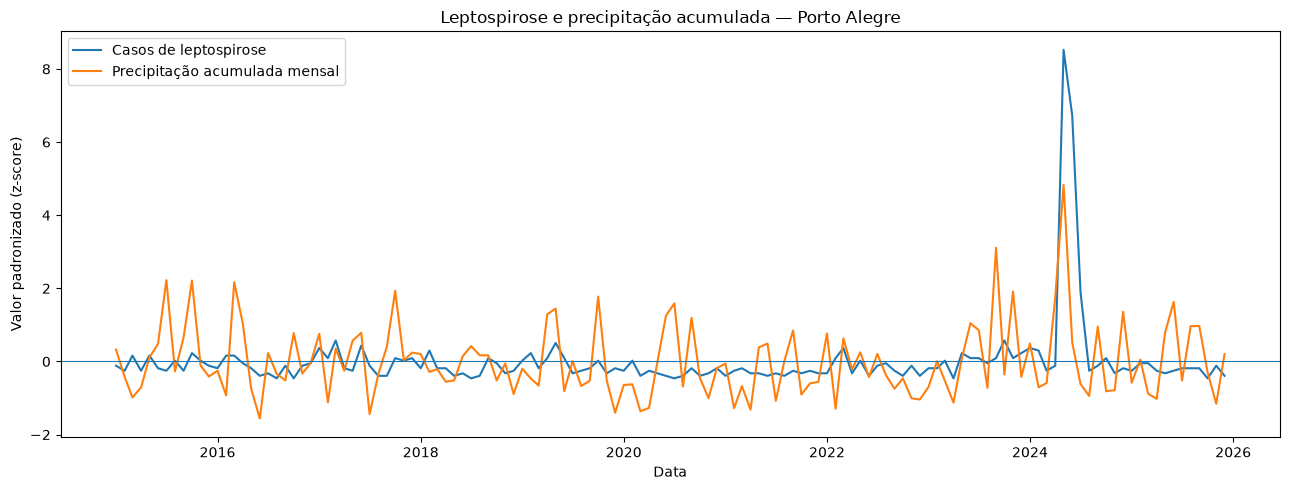

In [171]:
porto_lepto = (
    df[
        (df["municipality"] == "PORTO ALEGRE") &
        (df["disease"] == "LEPTOSPIROSE")
    ]
    .sort_values("reference_date")
    .copy()
)

porto_lepto["cases_z"] = (
    porto_lepto["cases"] - porto_lepto["cases"].mean()
) / porto_lepto["cases"].std()

porto_lepto["precip_sum_z"] = (
    porto_lepto["precipitation_sum_mm"]
    - porto_lepto["precipitation_sum_mm"].mean()
) / porto_lepto["precipitation_sum_mm"].std()

plt.figure(figsize=(13, 5))

plt.plot(
    porto_lepto["reference_date"],
    porto_lepto["cases_z"],
    label="Casos de leptospirose"
)

plt.plot(
    porto_lepto["reference_date"],
    porto_lepto["precip_sum_z"],
    label="Precipitação acumulada mensal"
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Data")
plt.ylabel("Valor padronizado (z-score)")
plt.title(
    "Leptospirose e precipitação acumulada — Porto Alegre"
)

plt.legend()
plt.tight_layout()
plt.show()

In [170]:
porto_2024 = (
    porto_lepto[
        porto_lepto["year"] == 2024
    ][[
        "reference_date",
        "cases",
        "precipitation_sum_mm",
        "precipitation_max_observation_mm"
    ]]
)

porto_2024

,reference_date,cases,precipitation_sum_mm,precipitation_max_observation_mm
17579,2024-01-01,12,173.7,46.8
17741,2024-02-01,11,76.4,16.0
17903,2024-03-01,3,85.8,17.8
18065,2024-04-01,5,275.4,25.8
18227,2024-05-01,130,523.9,21.2
18389,2024-06-01,104,175.8,19.8
18551,2024-07-01,34,83.6,6.0
18713,2024-08-01,3,57.3,6.4
18875,2024-09-01,5,210.6,18.4
19037,2024-10-01,8,67.6,8.4


In [154]:
municipal_summary = (
    municipality_corr_df[
        municipality_corr_df["n"] >= 60
    ]
    .groupby(
        ["disease", "climate_variable"]
    )
    .agg(
        municipios=("municipality", "count"),
        correlacao_mediana=("spearman", "median"),
        correlacao_media=("spearman", "mean"),
        minimo=("spearman", "min"),
        maximo=("spearman", "max")
    )
    .reset_index()
)

municipal_summary["correlacao_mediana_abs"] = (
    municipal_summary["correlacao_mediana"].abs()
)

municipal_summary.sort_values(
    ["disease", "correlacao_mediana_abs"],
    ascending=[True, False]
)

,disease,climate_variable,municipios,correlacao_mediana,correlacao_media,minimo,maximo,correlacao_mediana_abs
6,ASMA,temperature_avg_c,27,-0.264104,-0.238204,-0.560565,-0.018245,0.264104
0,ASMA,atmospheric_pressure_avg_mb,27,0.236547,0.219620,-0.033879,0.527684,0.236547
1,ASMA,dew_point_avg_c,27,-0.199270,-0.188578,-0.461829,0.023221,0.199270
5,ASMA,relative_humidity_avg_pct,27,0.189941,0.156346,-0.129252,0.569812,0.189941
3,ASMA,precipitation_max_observation_mm,27,-0.059679,-0.052692,-0.159076,0.107376,0.059679
8,ASMA,wind_speed_avg_ms,27,-0.048367,-0.019595,-0.295363,0.371001,0.048367
4,ASMA,precipitation_sum_mm,27,0.047112,0.049020,-0.149731,0.208917,0.047112
2,ASMA,precipitation_avg_observation_mm,27,0.037435,0.047570,-0.150885,0.195237,0.037435
7,ASMA,wind_gust_max_ms,27,-0.023335,-0.031309,-0.240134,0.170759,0.023335
15,BRONQUITE AGUDA,temperature_avg_c,27,-0.409919,-0.389332,-0.723497,-0.081262,0.409919


In [155]:
direction_summary = (
    municipality_corr_df[
        municipality_corr_df["n"] >= 60
    ]
    .assign(
        positiva=lambda x: x["spearman"] > 0,
        negativa=lambda x: x["spearman"] < 0
    )
    .groupby(
        ["disease", "climate_variable"]
    )
    .agg(
        municipios=("municipality", "count"),
        positivas=("positiva", "sum"),
        negativas=("negativa", "sum")
    )
    .reset_index()
)

direction_summary

,disease,climate_variable,municipios,positivas,negativas
0,ASMA,atmospheric_pressure_avg_mb,27,26,1
1,ASMA,dew_point_avg_c,27,1,26
2,ASMA,precipitation_avg_observation_mm,27,17,10
3,ASMA,precipitation_max_observation_mm,27,7,20
4,ASMA,precipitation_sum_mm,27,20,7
5,ASMA,relative_humidity_avg_pct,27,21,6
6,ASMA,temperature_avg_c,27,0,27
7,ASMA,wind_gust_max_ms,27,8,19
8,ASMA,wind_speed_avg_ms,27,11,16
9,BRONQUITE AGUDA,atmospheric_pressure_avg_mb,27,27,0


In [156]:
lepto_precip_summary = (
    lepto_precip_valid
    .agg(
        municipios=("municipality", "count"),
        correlacao_media=("spearman", "mean"),
        correlacao_mediana=("spearman", "median")
    )
)

lepto_precip_summary

,municipality,spearman
municipios,18.0,NaN
correlacao_media,NaN,0.087316
correlacao_mediana,NaN,0.054998


In [157]:
print(
    "Positivas:",
    (lepto_precip_valid["spearman"] > 0).sum()
)

print(
    "Negativas:",
    (lepto_precip_valid["spearman"] < 0).sum()
)

Positivas: 13
Negativas: 5


### Precipitação e leptospirose por município

A análise municipal evidenciou que a associação entre precipitação e casos de leptospirose não é homogênea entre os municípios.

Na análise agregada, a correlação entre precipitação média mensal e casos foi baixa. Entretanto, ao analisar cada município separadamente e restringir a avaliação àqueles com pelo menos 60 observações válidas, foram identificadas associações positivas de maior magnitude em municípios como Campo Bom, Canela, Cruz Alta, Santa Rosa e Porto Alegre.

Os resultados indicam que a agregação dos municípios pode reduzir a magnitude de relações locais e ocultar heterogeneidade espacial. Ao mesmo tempo, as correlações permanecem majoritariamente fracas a moderadas, sugerindo que a precipitação média mensal isoladamente não é suficiente para explicar a ocorrência de leptospirose.

Também não foi observada uma relação direta entre o tamanho aparente do município e a magnitude da correlação. O tamanho populacional influencia a quantidade absoluta de casos, mas não determina necessariamente a intensidade da associação entre precipitação e ocorrência da doença.

Esses resultados reforçam a necessidade de considerar diferenças municipais durante a modelagem e de evitar interpretações baseadas exclusivamente em dados agregados.

### Consistência espacial — precipitação e leptospirose

Após restringir a análise aos municípios com pelo menos 60 observações válidas, 18 municípios permaneceram na análise.

Desses municípios, 13 (72,2%) apresentaram correlação positiva entre precipitação média e casos de leptospirose, enquanto 5 (27,8%) apresentaram correlação negativa.

Apesar da predominância de associações positivas, a magnitude das correlações foi geralmente baixa, com correlação média de 0,087 e mediana de 0,055.

O resultado sugere que existe certa consistência espacial na direção da associação entre precipitação e leptospirose, porém a precipitação média mensal, isoladamente, apresenta baixo poder explicativo.

Esse resultado também motiva a avaliação de outras representações da precipitação, como precipitação acumulada mensal, eventos extremos e defasagens temporais, que podem representar melhor os mecanismos ambientais associados à ocorrência de leptospirose.

In [178]:
# Percentil 90 da precipitação mensal de cada município
df["precipitation_p90"] = (
    df.groupby("municipality")["precipitation_sum_mm"]
      .transform(lambda x: x.quantile(0.90))
)

# 1 = mês de chuva extrema
# 0 = mês normal
df["extreme_rain"] = (
    df["precipitation_sum_mm"] >= df["precipitation_p90"]
).astype(int)

In [179]:
df[
    [
        "municipality",
        "reference_date",
        "precipitation_sum_mm",
        "precipitation_p90",
        "extreme_rain"
    ]
].head(20)

,municipality,reference_date,precipitation_sum_mm,precipitation_p90,extreme_rain
0,BAGE,2015-01-01,207.4,229.4,0
1,BAGE,2015-01-01,207.4,229.4,0
2,BAGE,2015-01-01,207.4,229.4,0
3,BAGE,2015-01-01,207.4,229.4,0
4,BAGE,2015-01-01,207.4,229.4,0
5,BAGE,2015-01-01,207.4,229.4,0
6,BENTO GONCALVES,2015-01-01,135.2,250.0,0
7,BENTO GONCALVES,2015-01-01,135.2,250.0,0
8,BENTO GONCALVES,2015-01-01,135.2,250.0,0
9,BENTO GONCALVES,2015-01-01,135.2,250.0,0


In [180]:
lepto = df[
    df["disease"] == "LEPTOSPIROSE"
].copy()

extreme_summary = (
    lepto
    .groupby("extreme_rain")
    .agg(
        observacoes=("cases", "count"),
        media_casos=("cases", "mean"),
        mediana_casos=("cases", "median"),
        total_casos=("cases", "sum"),
        max_casos=("cases", "max")
    )
    .reset_index()
)

extreme_summary

,extreme_rain,observacoes,media_casos,mediana_casos,total_casos,max_casos
0,0,1977,0.683864,0.0,1352,104
1,1,231,1.467532,0.0,339,130


In [181]:
cases_extreme = lepto.loc[
    lepto["extreme_rain"] == 1,
    "cases"
].sum()

cases_normal = lepto.loc[
    lepto["extreme_rain"] == 0,
    "cases"
].sum()

total_cases = lepto["cases"].sum()

print("Casos em meses extremos:", cases_extreme)
print("Casos em meses normais:", cases_normal)

print(
    "% dos casos em meses extremos:",
    round(cases_extreme / total_cases * 100, 2)
)

Casos em meses extremos: 339
Casos em meses normais: 1352
% dos casos em meses extremos: 20.05


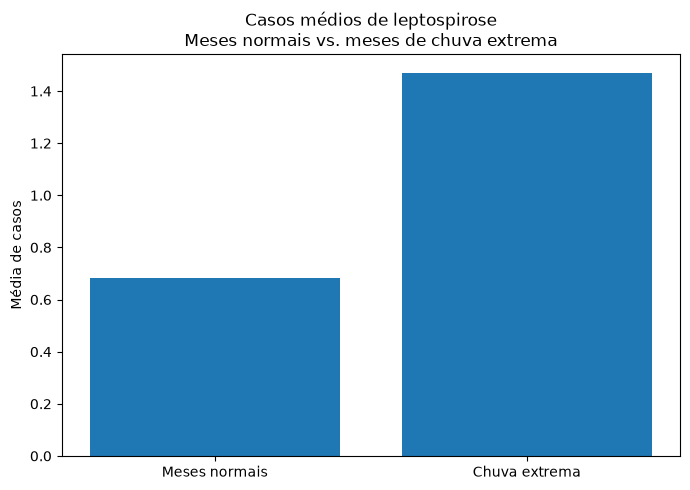

In [182]:
import matplotlib.pyplot as plt

plot_data = (
    lepto
    .groupby("extreme_rain")["cases"]
    .mean()
)

plt.figure(figsize=(7, 5))

plt.bar(
    ["Meses normais", "Chuva extrema"],
    plot_data.values
)

plt.ylabel("Média de casos")
plt.title(
    "Casos médios de leptospirose\n"
    "Meses normais vs. meses de chuva extrema"
)

plt.tight_layout()
plt.show()

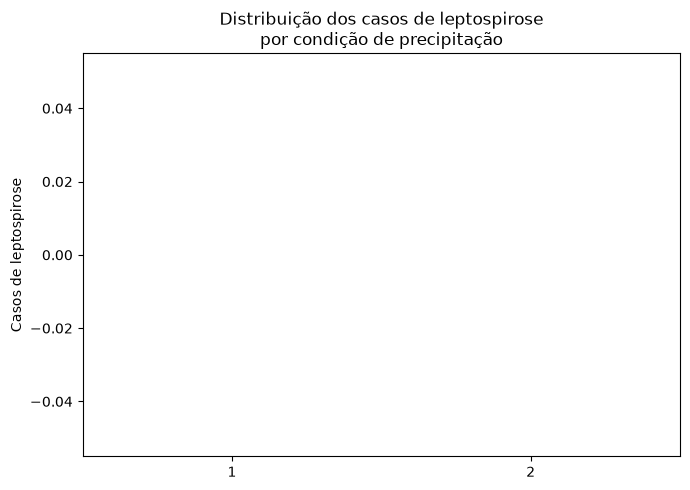

In [184]:
normal = lepto.loc[
    lepto["extreme_rain"] == 0,
    "cases"
]

extreme = lepto.loc[
    lepto["extreme_rain"] == 1,
    "cases"
]

plt.figure(figsize=(7, 5))

plt.boxplot(
    [normal, extreme],
    label=["Meses normais", "Chuva extrema"],
    showfliers=False
)

plt.ylabel("Casos de leptospirose")
plt.title(
    "Distribuição dos casos de leptospirose\n"
    "por condição de precipitação"
)

plt.tight_layout()
plt.show()

### Eventos extremos de precipitação e leptospirose

Os meses classificados como de precipitação extrema, definidos a partir do percentil 90 da precipitação acumulada mensal de cada município, representaram aproximadamente 10,5% das observações analisadas.

Apesar disso, esses períodos concentraram 20,05% dos casos de leptospirose registrados. A média foi de aproximadamente 1,47 caso nos períodos de precipitação extrema, contra 0,68 nos demais períodos, correspondendo a uma média aproximadamente 2,15 vezes superior.

A mediana permaneceu igual a zero em ambos os grupos, indicando elevada frequência de observações sem ocorrência de casos. Ao mesmo tempo, foram observados valores máximos elevados, principalmente durante períodos associados a eventos extremos.

Os resultados sugerem que a associação entre precipitação e leptospirose pode não apresentar comportamento monotônico simples. Em vez disso, eventos extremos de precipitação podem estar associados a aumentos desproporcionais no número de casos. Essa hipótese será posteriormente avaliada por meio dos modelos estatísticos, sem atribuição causal a partir da análise exploratória.

In [185]:
distribution_summary = (
    df
    .groupby("disease")["cases"]
    .agg(
        n="count",
        media="mean",
        variancia="var",
        mediana="median",
        minimo="min",
        maximo="max"
    )
    .reset_index()
)

distribution_summary["variance_mean_ratio"] = (
    distribution_summary["variancia"]
    / distribution_summary["media"]
)

distribution_summary

,disease,n,media,variancia,mediana,minimo,maximo,variance_mean_ratio
0,ASMA,3564,7.394781,971.278569,1.0,0,359,131.346493
1,BRONQUITE AGUDA,3564,10.91835,2686.668324,1.0,0,644,246.069075
2,BRONQUITE CRÔNICA,3564,10.952862,714.675296,5.0,0,233,65.250096
3,INFARTO AGUDO DO MIOCÁRDIO,3564,17.122054,2483.433597,2.0,0,390,145.042973
4,INSUFICIÊNCIA CARDÍACA,3564,20.349046,2804.829017,8.0,0,428,137.835897
5,LEPTOSPIROSE,2208,0.765851,15.439033,0.0,0,130,20.159305


In [187]:
zero_summary = (
    df
    .assign(
        zero=df["cases"].eq(0).fillna(False).astype(int)
    )
    .groupby("disease")
    .agg(
        observacoes=("cases", "count"),
        zeros=("zero", "sum")
    )
    .reset_index()
)

zero_summary["percentual_zeros"] = (
    zero_summary["zeros"]
    / zero_summary["observacoes"]
    * 100
)

zero_summary

,disease,observacoes,zeros,percentual_zeros
0,ASMA,3564,1299,36.447811
1,BRONQUITE AGUDA,3564,1571,44.079686
2,BRONQUITE CRÔNICA,3564,306,8.585859
3,INFARTO AGUDO DO MIOCÁRDIO,3564,1139,31.958474
4,INSUFICIÊNCIA CARDÍACA,3564,157,4.405163
5,LEPTOSPIROSE,2208,1539,69.701087


### Sobredispersão dos casos epidemiológicos

A análise da distribuição da variável `cases` revelou forte sobredispersão em todas as doenças estudadas.

Em todos os casos, a variância foi substancialmente superior à média. A razão entre variância e média variou de aproximadamente 20 para leptospirose até 246 para bronquite aguda.

Esse comportamento indica que a hipótese de equidispersão, característica de um modelo de Poisson simples, não é compatível com a distribuição observada dos dados.

Também foram observadas distribuições fortemente assimétricas, com medianas consideravelmente inferiores às médias e valores máximos muito superiores à maior parte das observações.

Esses resultados justificam a avaliação de modelos apropriados para dados de contagem sobredispersos, especialmente a Regressão Binomial Negativa. O modelo de Poisson poderá ser utilizado posteriormente como referência comparativa, enquanto o OLS será mantido como baseline estatístico.

### Frequência de observações com zero casos

A análise da frequência de zeros mostra diferenças importantes entre as doenças estudadas.

A leptospirose apresenta a maior proporção de observações sem registro de casos, com aproximadamente 69,7% das observações válidas iguais a zero. Esse comportamento é coerente com a característica mais esparsa da série, na qual muitos municípios e meses não apresentam casos registrados.

Também foram observadas proporções relevantes de zeros para bronquite aguda (44,1%), asma (36,4%) e infarto agudo do miocárdio (32,0%). Em contraste, bronquite crônica (8,6%) e insuficiência cardíaca (4,4%) apresentam séries consideravelmente menos esparsas.

A elevada frequência de zeros, especialmente para leptospirose, deve ser considerada durante a etapa de modelagem. Em conjunto com a forte sobredispersão identificada anteriormente, esses resultados reforçam o uso da Regressão Binomial Negativa como um dos principais modelos candidatos.

Para a leptospirose, também poderá ser avaliado posteriormente se a quantidade de zeros observada é adequadamente explicada pela distribuição Binomial Negativa ou se modelos específicos para excesso de zeros, como Zero-Inflated Negative Binomial (ZINB), apresentam melhor ajuste.

In [188]:
climate_vars = [
    "precipitation_sum_mm",
    "precipitation_avg_observation_mm",
    "precipitation_max_observation_mm",
    "temperature_avg_c",
    "dew_point_avg_c",
    "relative_humidity_avg_pct",
    "atmospheric_pressure_avg_mb",
    "wind_speed_avg_ms",
    "wind_gust_max_ms"
]

climate_corr = (
    df[climate_vars]
    .corr(method="spearman")
    .round(3)
)

climate_corr

,precipitation_sum_mm,precipitation_avg_observation_mm,precipitation_max_observation_mm,temperature_avg_c,dew_point_avg_c,relative_humidity_avg_pct,atmospheric_pressure_avg_mb,wind_speed_avg_ms,wind_gust_max_ms
precipitation_sum_mm,1.000,0.970,0.662,-0.082,0.103,0.431,-0.114,0.005,0.259
precipitation_avg_observation_mm,0.970,1.000,0.651,-0.082,0.107,0.436,-0.117,0.005,0.242
precipitation_max_observation_mm,0.662,0.651,1.000,0.292,0.374,0.112,-0.095,-0.051,0.233
temperature_avg_c,-0.082,-0.082,0.292,1.000,0.903,-0.463,0.150,-0.132,0.047
dew_point_avg_c,0.103,0.107,0.374,0.903,1.000,-0.086,0.153,-0.152,0.045
relative_humidity_avg_pct,0.431,0.436,0.112,-0.463,-0.086,1.000,-0.079,-0.020,0.001
atmospheric_pressure_avg_mb,-0.114,-0.117,-0.095,0.150,0.153,-0.079,1.000,-0.252,-0.152
wind_speed_avg_ms,0.005,0.005,-0.051,-0.132,-0.152,-0.020,-0.252,1.000,0.400
wind_gust_max_ms,0.259,0.242,0.233,0.047,0.045,0.001,-0.152,0.400,1.000


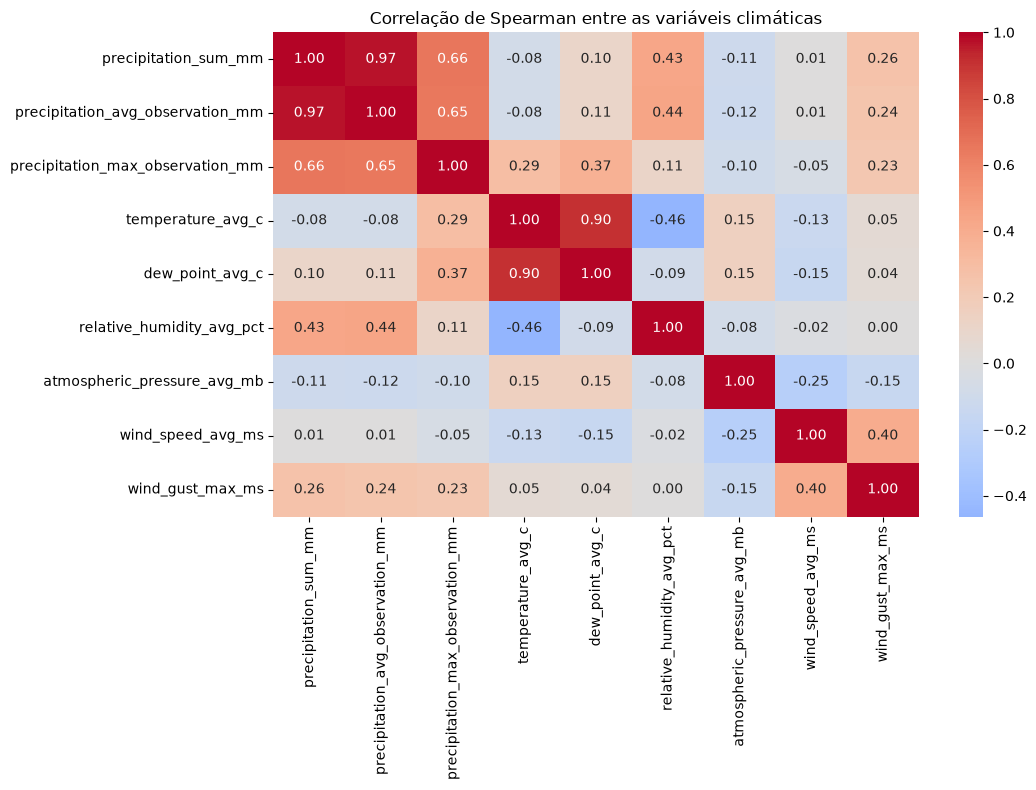

In [190]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(11, 8))

sns.heatmap(
    climate_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlação de Spearman entre as variáveis climáticas")
plt.tight_layout()
plt.show()

### Correlação entre as variáveis climáticas

A matriz de correlação de Spearman entre as variáveis climáticas revelou algumas relações fortes que devem ser consideradas durante a etapa de modelagem.

A maior correlação foi observada entre a precipitação acumulada mensal (`precipitation_sum_mm`) e a precipitação média por observação (`precipitation_avg_observation_mm`), com coeficiente de aproximadamente 0,97. Esse resultado indica elevada redundância entre as duas métricas.

Também foi observada forte correlação positiva entre temperatura média (`temperature_avg_c`) e ponto de orvalho médio (`dew_point_avg_c`), com coeficiente de aproximadamente 0,90.

A precipitação máxima observada apresentou correlação de aproximadamente 0,66 com a precipitação acumulada e 0,65 com a precipitação média por observação. Embora relacionadas, essas variáveis representam características distintas dos eventos de precipitação, especialmente a diferença entre volume acumulado e ocorrência de episódios extremos.

As demais relações apresentaram magnitudes menores, destacando-se a correlação negativa entre temperatura e umidade relativa (-0,46) e a correlação positiva entre velocidade média e rajada máxima do vento (0,40).

Diante desses resultados, variáveis altamente correlacionadas não deverão ser incluídas indiscriminadamente em uma mesma especificação de regressão. Durante a modelagem serão avaliadas diferentes combinações de variáveis, especialmente para as métricas de precipitação, a fim de reduzir problemas de multicolinearidade e comparar sua capacidade explicativa.